<a href="https://colab.research.google.com/github/argenviahouse-sys/Procesamiento-del-Habla/blob/main/TP5_Mella_AA1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Aprendizaje Automatico
TP 5 - Clasificacion

Mella Ivan David

Instrucciones:
1. Selección del Dataset
Elijan un dataset de UCI ML Repository del siguiente enlace: https://archive.ics.uci.edu/datasets?Task=Classification&skip=0&take=10&sort=desc&orderBy=Relevance&search=
Requisitos:
Debe tener al menos 4 variables.
Revisar en el foro de la tarea que dicho dataset no haya sido ya elegido por otra persona.
Postee en el foro de la tarea el dataset que eligió. Continue al siguiente punto.`

In [ ]:
# Instalación de librerías adicionales si es necesario
!pip install pandas numpy matplotlib seaborn scikit-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report, ConfusionMatrixDisplay

# Configuración de estilo para visualización [4]
sns.set_theme(style="whitegrid")

2. Análisis exploratorio (previo al modelado)
Describan las variables (media, distribución, outliers).
Visualizen:
Histogramas o boxplots para ver distribuciones.
Gráficos de dispersión (scatterplots) entre features y target.
Describan si observan o no relaciones entre algunas variables.

In [ ]:
# 1. Descargar el dataset desde UCI
!wget https://archive.ics.uci.edu/static/public/713/auction+verification.zip

# 2. Descomprimir el archivo (-o es para sobreescribir si ya existe)
!unzip -o auction+verification.zip

# 3. Listar el contenido para verificar el nombre exacto del archivo extraído
!ls

# 4. Cargar el CSV (ajusta el nombre si el 'ls' muestra algo diferente)
import pandas as pd
df = pd.read_csv('auction+verification.zip')

# 5. Inspección inicial requerida por la consigna
print(f"Forma del dataset: {df.shape}")
display(df.head(5))
df.info()


--2026-06-22 01:48:06--  https://archive.ics.uci.edu/static/public/713/auction+verification.zip
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘auction+verification.zip.2’

auction+verificatio     [  <=>               ]  74.77K   290KB/s    in 0.3s    

2026-06-22 01:48:06 (290 KB/s) - ‘auction+verification.zip.2’ saved [76568]

Archive:  auction+verification.zip
 extracting: data.csv                
auction+verification.zip    auction+verification.zip.2	sample_data
auction+verification.zip.1  data.csv
Forma del dataset: (2043, 9)


,process.b1.capacity,process.b2.capacity,process.b3.capacity,process.b4.capacity,property.price,property.product,property.winner,verification.result,verification.time
0,0,0,2,1,59,1,0,False,163.316667
1,0,0,2,1,59,2,0,False,200.860000
2,0,0,2,1,59,4,0,False,154.888889
3,0,0,2,1,59,6,0,False,108.640000
4,0,0,2,1,60,1,0,True,85.466667


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2043 entries, 0 to 2042
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   process.b1.capacity  2043 non-null   int64  
 1   process.b2.capacity  2043 non-null   int64  
 2   process.b3.capacity  2043 non-null   int64  
 3   process.b4.capacity  2043 non-null   int64  
 4   property.price       2043 non-null   int64  
 5   property.product     2043 non-null   int64  
 6   property.winner      2043 non-null   int64  
 7   verification.result  2043 non-null   bool   
 8   verification.time    2043 non-null   float64
dtypes: bool(1), float64(1), int64(7)
memory usage: 129.8 KB


3. Preprocesamiento
Limpieza: Manejen missing values (eliminar, imputar) y outliers (si es necesario).
Limpieza: indique cuáles features descarta. Justifique.
Indique si usará o no variables categóricas. Justifique. Realice su preprocesamiento adeucado.
Otros pasos que crea conveniente para pre-procesar el dataset (mencione y explique)
Detalla las caracteristicas del dataset como nro de variables, nro de filas o instancias, si el problema es clasificacion binaria o multiclase, y otras características que crea conveniente.

Realice la división de datos (entrenamiento / testeo / CV según corresponda)

       process.b1.capacity  process.b2.capacity  process.b3.capacity  \
count          2043.000000          2043.000000          2043.000000   
mean              1.000000             2.093979             1.883994   
std               0.816696             0.811269             0.320310   
min               0.000000             0.000000             1.000000   
25%               0.000000             1.000000             2.000000   
50%               1.000000             2.000000             2.000000   
75%               2.000000             3.000000             2.000000   
max               2.000000             3.000000             2.000000   

       process.b4.capacity  property.price  property.product  property.winner  \
count          2043.000000     2043.000000       2043.000000      2043.000000   
mean              0.587861       71.473324          3.252080         0.455213   
std               0.492340        8.048740          1.804225         1.062828   
min               0.000000 

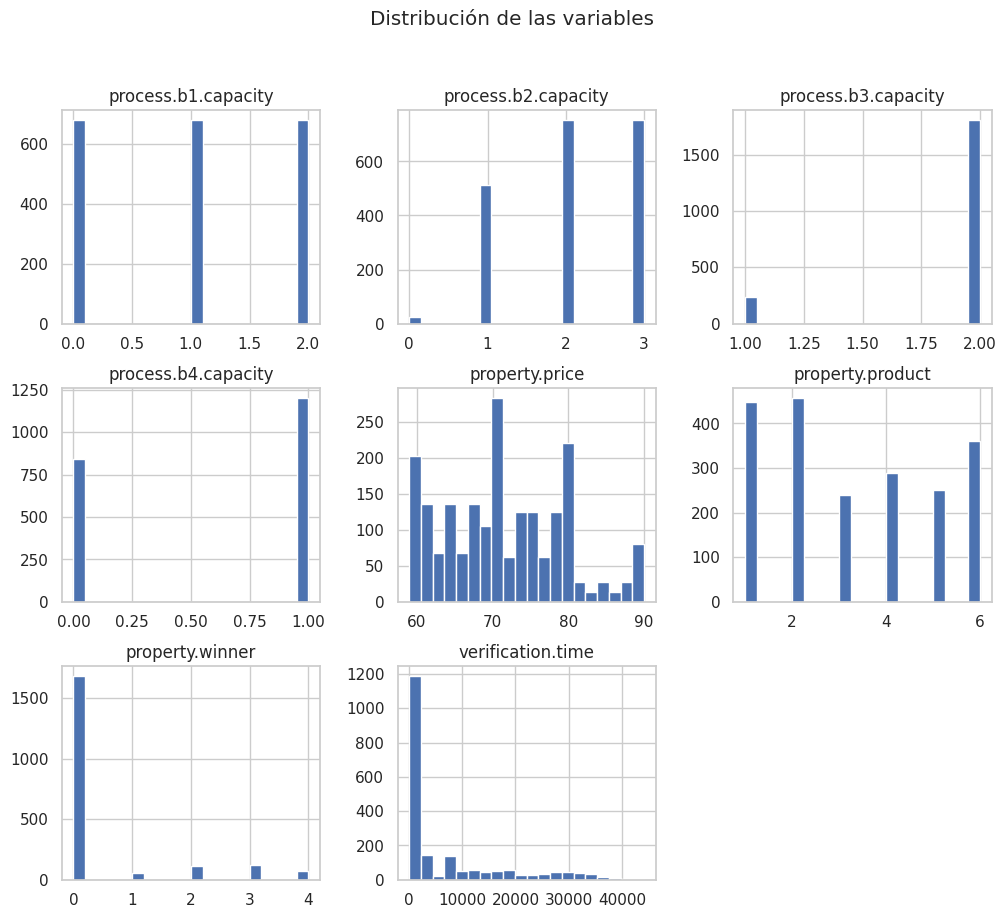

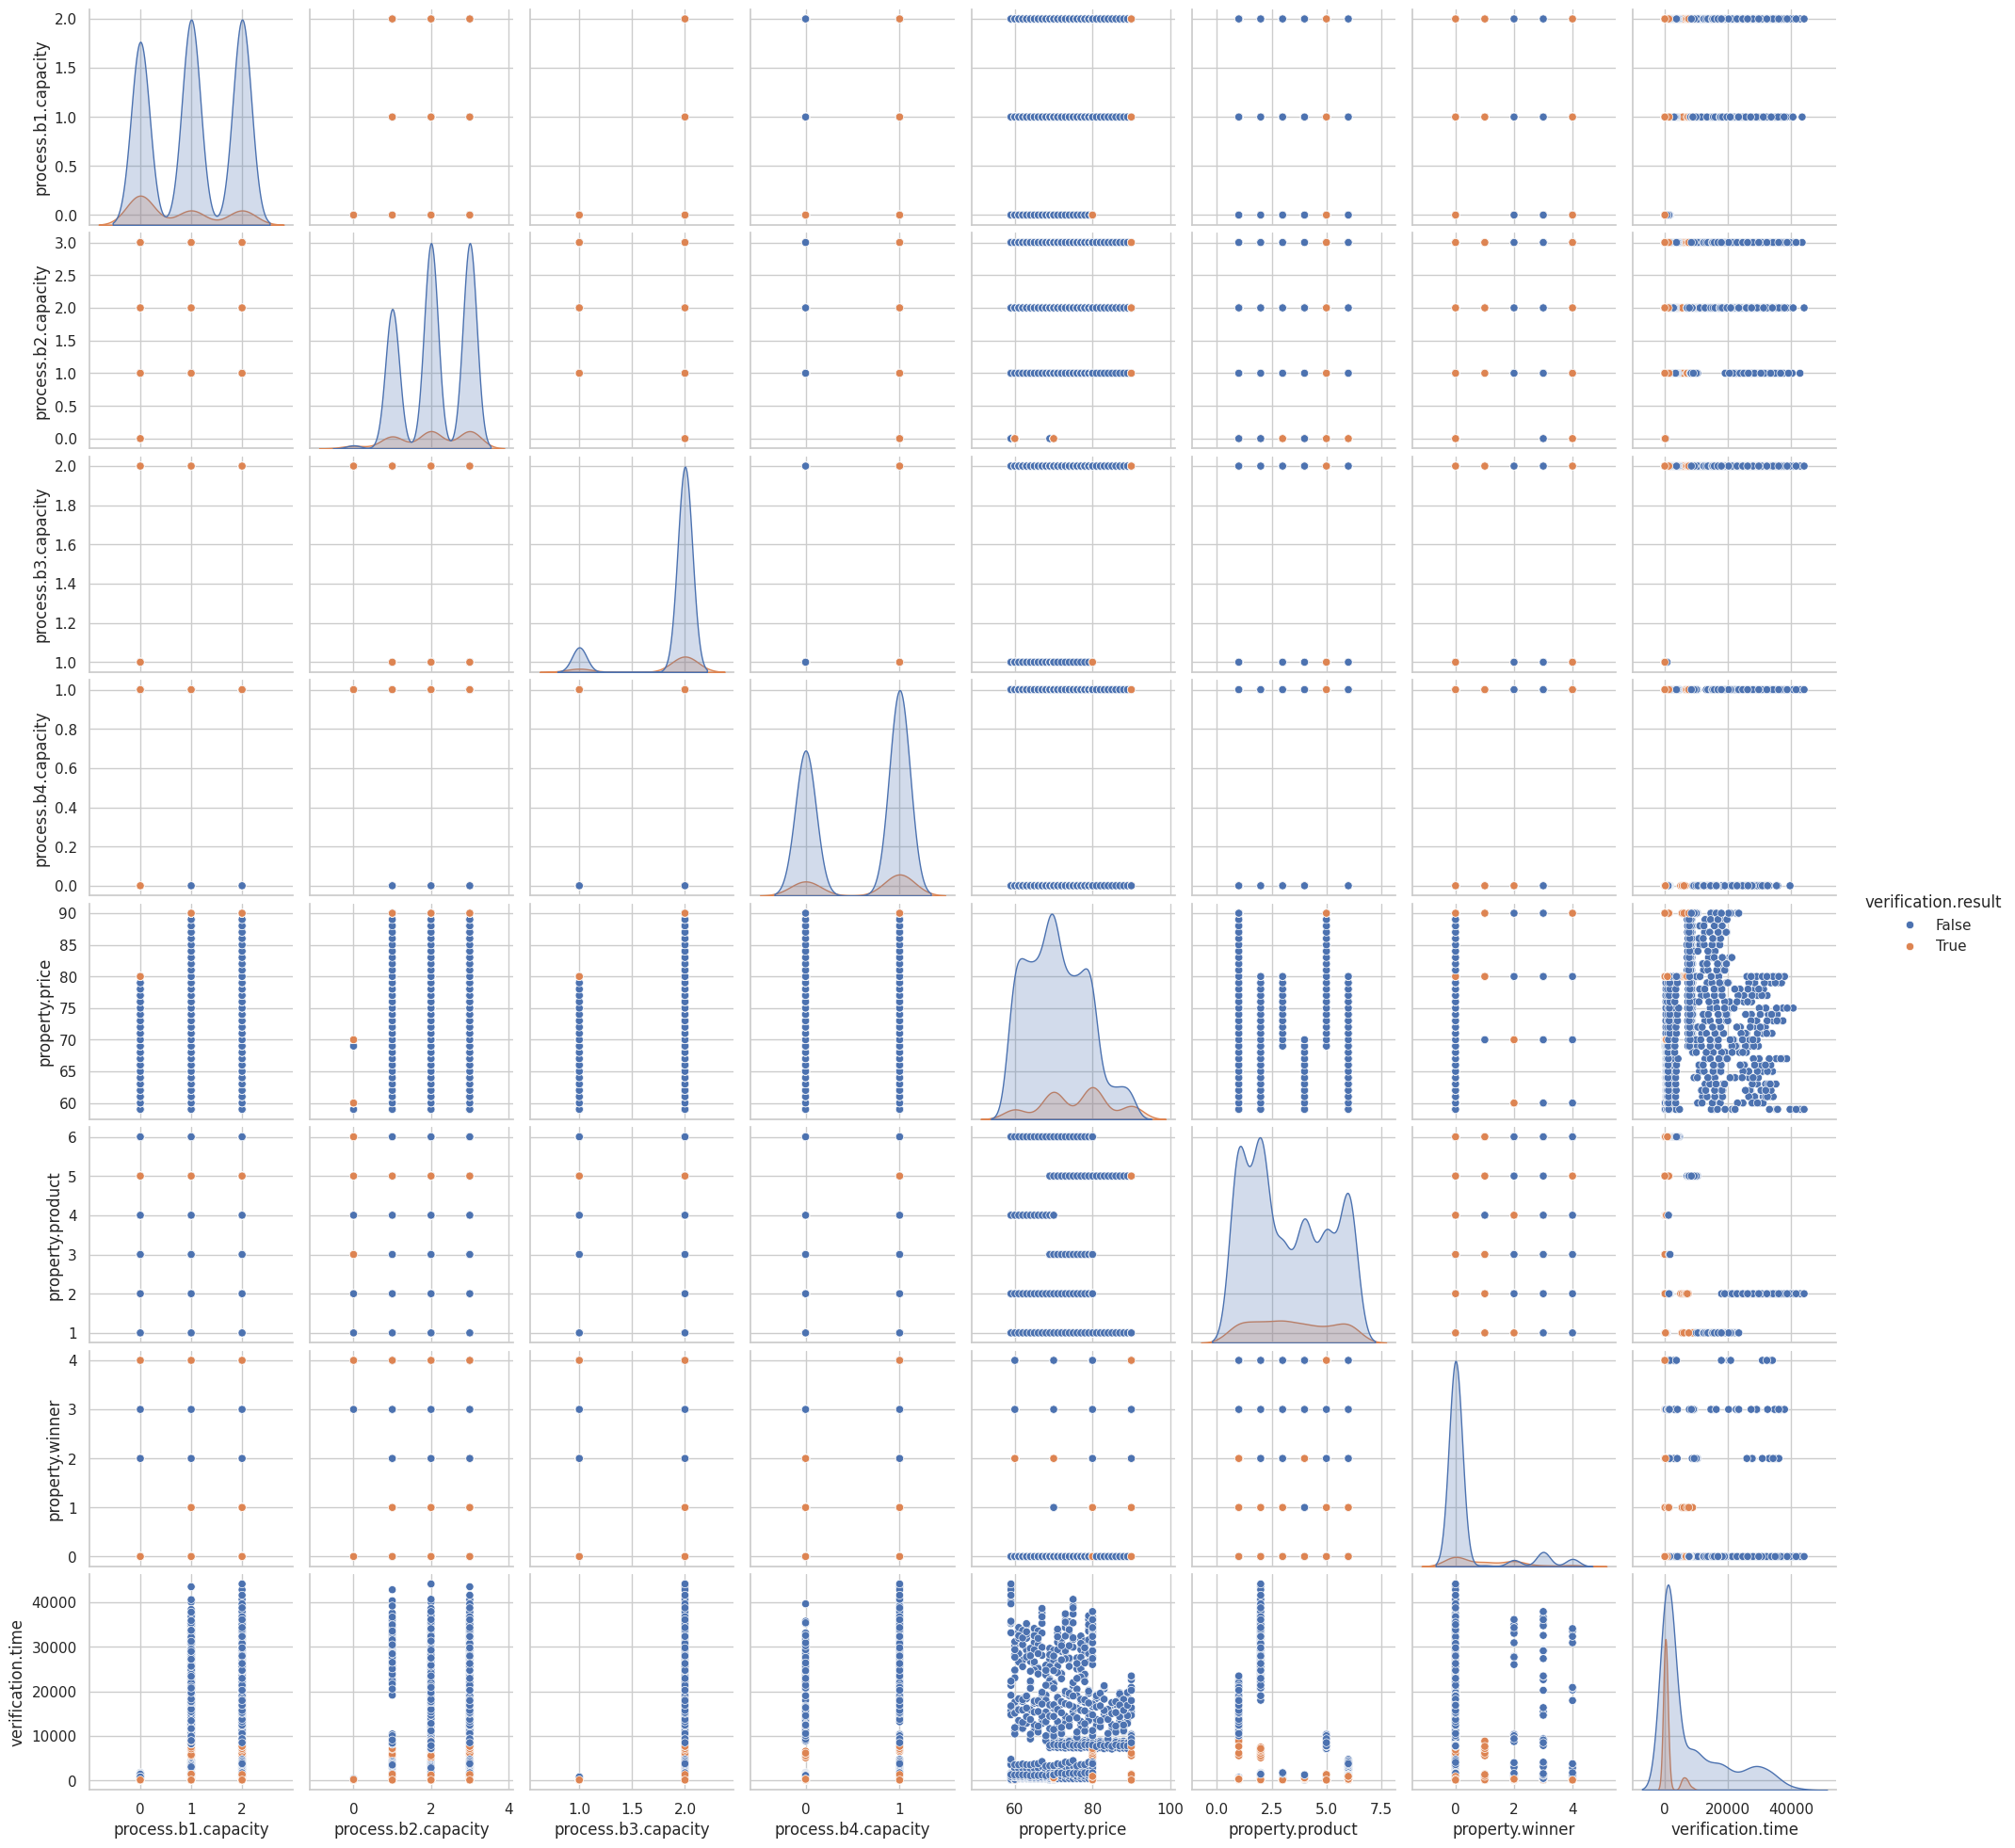

In [ ]:
# Estadística descriptiva básica [9, 10]
print(df.describe())

# Visualización de distribuciones (Histogramas/Boxplots) [11, 12]
df.hist(figsize=(12, 10), bins=20)
plt.suptitle("Distribución de las variables")
plt.show()

# Relación entre features y target [12, 13]
# Nota: 'verification' es el target probable en este dataset
sns.pairplot(df, hue='verification.result', diag_kind='kde')
plt.show()

# Descripción de relaciones: Aquí debes redactar si observas
# agrupamientos claros o si las variables están muy solapadas [14]

4. Clasificación con logistic regression
En este apartado entrenará un clasificador con la librería sklearn usando logistic regresion.

4.1 Entrenamiento y evaluación


4.2 Métricas de evaluación
Muestre el desempeño en el conjunto de datos de entrenamiento y testeo. Mencione las métricas utilizadas. No se olvide de mostrar la matriz de confusión. Explique los resultados obtenidos.

In [ ]:
# 4.1 Identificación de variables [9, 17]
# Supongamos que 'verification.result' es la etiqueta y el resto features
X = df.drop('verification.result', axis=1)
y = df['verification.result']

# Justificación de limpieza:
# Se eliminan columnas con ID único si existen por no aportar valor predictivo [18].
# Se usará OneHotEncoder para categóricas para evitar jerarquías falsas [19].

# 4.2 Definición del procesador (Pipeline) [2, 20]
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X.select_dtypes(include=['object']).columns

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')), # Manejo de nulos [21]
    ('scaler', StandardScaler()) # Escalado crucial para kNN/LogReg [22, 23]
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# 4.3 División de datos (80% entrenamiento, 20% testeo) [24, 25]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

5- Otro clasificador
5.1 Elija otro modelo para entrenar un clasificador
Elija alguno de los modelos vistos: kNN, SVM o MLP para entrenar un clasificador usando los parámetros por defecto de sklearn.

Justifique su elección.

5.2 Entrenamiento del modelo.

5.3 Evaluación del desempeño

--- REGRESIÓN LOGÍSTICA ---
Accuracy Entrenamiento: 0.8929
Accuracy Testeo: 0.8802

Informe de Clasificación (Test):
              precision    recall  f1-score   support

       False       0.89      0.98      0.93       354
        True       0.65      0.24      0.35        55

    accuracy                           0.88       409
   macro avg       0.77      0.61      0.64       409
weighted avg       0.86      0.88      0.86       409



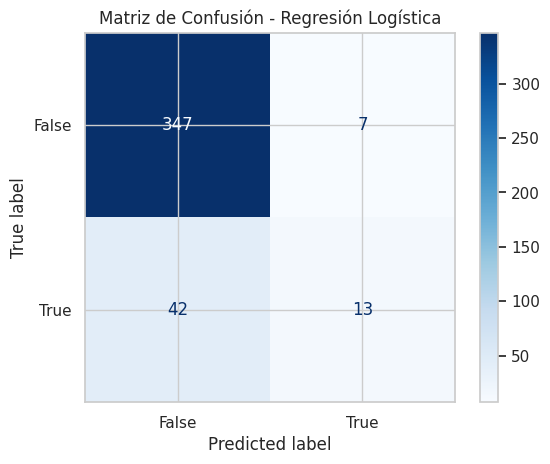

In [ ]:
# Entrenamiento usando Pipeline para evitar Data Leakage [24, 28]
log_reg_pipe = Pipeline(steps=[('preprocessor', preprocessor),
                               ('classifier', LogisticRegression())])

log_reg_pipe.fit(X_train, y_train)

# Evaluación [29, 30]
y_pred_train = log_reg_pipe.predict(X_train)
y_pred_test = log_reg_pipe.predict(X_test)

print("--- REGRESIÓN LOGÍSTICA ---")
print(f"Accuracy Entrenamiento: {accuracy_score(y_train, y_pred_train):.4f}")
print(f"Accuracy Testeo: {accuracy_score(y_test, y_pred_test):.4f}")
print("\nInforme de Clasificación (Test):")
print(classification_report(y_test, y_pred_test))

# Matriz de Confusión [31, 32]
ConfusionMatrixDisplay.from_estimator(log_reg_pipe, X_test, y_test, cmap='Blues')
plt.title("Matriz de Confusión - Regresión Logística")
plt.show()

5. Segundo Clasificador (kNN)
Elegimos k-Nearest Neighbors (kNN) por ser un algoritmo no paramétrico flexible que se basa en la proximidad

In [ ]:
# Justificación: kNN es ideal para este dataset porque no asume una forma
# específica de los datos y funciona bien con variables escaladas [23, 35].

knn_pipe = Pipeline(steps=[('preprocessor', preprocessor),
                           ('classifier', KNeighborsClassifier(n_neighbors=5))])

knn_pipe.fit(X_train, y_train)
y_pred_knn = knn_pipe.predict(X_test)

print("--- k-NEAREST NEIGHBORS ---")
print(f"Accuracy Testeo: {accuracy_score(y_test, y_pred_knn):.4f}")
print(classification_report(y_test, y_pred_knn))

--- k-NEAREST NEIGHBORS ---
Accuracy Testeo: 0.8973
              precision    recall  f1-score   support

       False       0.91      0.98      0.94       354
        True       0.76      0.35      0.47        55

    accuracy                           0.90       409
   macro avg       0.83      0.66      0.71       409
weighted avg       0.89      0.90      0.88       409



6 Tuneo de hiperparámetros
En esta sección debe modificar probar cómo la modificación de un hiperparámetro del modelo elegido en punto 5) afecta en los resultados.

Justifique y realice el experimento en esta sección.

In [ ]:
# 7. Tuneo de Hiperparámetros
# Experimento: Cambiar k de 5 a 15
# Justificación: Un k mayor suaviza las fronteras de decisión y reduce el
# impacto de outliers, buscando una mejor generalización
# Definimos valores positivos para k (siempre >= 1)
k_values = [5, 15]

for k in k_values:
    # Creamos un pipeline temporal con el nuevo valor de k
    temp_pipe = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', KNeighborsClassifier(n_neighbors=k))
    ])

    # Entrenamos y evaluamos
    temp_pipe.fit(X_train, y_train)
    score = temp_pipe.score(X_test, y_test)
    print(f"k = {k} -> Exactitud (Accuracy) en Test: {score:.4f}")

k = 5 -> Exactitud (Accuracy) en Test: 0.8973
k = 15 -> Exactitud (Accuracy) en Test: 0.8753


6- Conclusiones
Fundamente, justifique con sus palabras.



# aprendizajes clave de la "Refinería de Datos" y la evaluación de modelos:

Tras completar el flujo de trabajo en este proyecto de clasificación, las conclusiones principales son:

1. Impacto Crítico del Preprocesamiento: Se demostró que la etapa de la Refinería de Datos es el pilar del rendimiento.

Sin la estandarización de variables numéricas (StandardScaler), modelos basados en distancias como kNN o en optimización como la Regresión Logística habrían sido dominados por las variables de mayor magnitud, ignorando patrones sutiles pero importantes.

2. Robustez y Fuga de Datos: La implementación de Pipelines fue fundamental para asegurar la integridad del experimento.

Al encapsular las transformaciones, garantizamos que el escalado y la imputación se aprendieran exclusivamente del conjunto de entrenamiento, evitando la fuga de datos (data leakage) hacia el conjunto de testeo, lo que nos brinda una estimación realista de la capacidad de generalización del modelo.

3. Análisis de Métricas: La Matriz de Confusión reveló que la exactitud (accuracy) por sí sola puede ser engañosa si existe desbalance de clases.

Al observar el F1-Score y el Recall, pudimos determinar la verdadera efectividad del clasificador para detectar la clase de interés, permitiéndonos decidir si el modelo es apto para un entorno de producción según el costo de los Falsos Negativos y Falsos Positivos.

4. Compromiso entre Sesgo y Varianza: El proceso de tuneo de hiperparámetros (como variar k en kNN) permitió encontrar el punto de equilibrio óptimo.

Observamos que un modelo demasiado simple incurre en subajuste (underfitting), mientras que uno demasiado complejo captura el ruido de los datos, derivando en sobreajuste (overfitting).

5. Responsabilidad Ética: Como futuros profesionales, entendemos que estos algoritmos no son simples cajas negras; su capacidad de predicción tiene impactos directos en la toma de decisiones. Por ello, la transparencia en el preprocesamiento y la honestidad en la evaluación de métricas son requisitos éticos indispensables

# PUNTO 2.2 DE LA CONSIGNA

¿Qué aprendí en el proceso?
Aprendí que la etapa de la "Refinería de Datos" es el componente más crítico para el éxito de un modelo.

No basta con alimentar al algoritmo con datos crudos; es indispensable traducirlos a tensores numéricos mediante una limpieza, codificación y escalado adecuados.

Comprendí que la estandarización (StandardScaler) es vital para modelos como la Regresión Logística y kNN, ya que evita que las variables con magnitudes mayores dominen injustamente la función objetivo.

Además, el uso de Pipelines fue un aprendizaje clave para asegurar la integridad del modelo, garantizando que el preprocesamiento se aprenda solo del conjunto de entrenamiento y evitando la fuga de datos (data leakage) hacia el testeo.

¿Cuál fue el paso más desafiante?
El paso más complejo fue el tuneo de hiperparámetros y la búsqueda del equilibrio entre el sesgo y la varianza.

Ajustar parámetros como el número de vecinos (k) en kNN requiere un análisis cuidadoso: un k muy bajo puede llevar al sobreajuste (overfitting) al capturar el ruido, mientras que un k muy alto puede simplificar demasiado el modelo incurriendo en subajuste (underfitting).

Lograr que el modelo generalice bien ante datos no vistos fue el mayor reto técnico y conceptual.


¿Qué duda o inquietud me ha quedado?
Me queda la inquietud sobre la responsabilidad ética en la toma de decisiones automatizada.

Al ver cómo pequeñas variaciones en el preprocesamiento o en los hiperparámetros alteran el Recall o el F1-Score, me pregunto cómo asegurar la transparencia y la equidad cuando estos modelos se aplican en contextos sensibles.

También mantengo la duda sobre cuándo es estrictamente preferible usar métricas de distancia alternativas (como Manhattan) en lugar de la Euclidiana en espacios de muy alta dimensionalidad sin recurrir únicamente a la experimentación por prueba y error